
=== Learning Rate: 0.001 ===
Iteration 0: m=0.0017, c=0.0089, Cost=20.4238
Iteration 100: m=0.1560, c=0.8124, Cost=13.6870
Iteration 200: m=0.2823, c=1.4701, Cost=9.1730
Iteration 300: m=0.3857, c=2.0085, Cost=6.1483
Iteration 400: m=0.4704, c=2.4492, Cost=4.1217
Iteration 500: m=0.5397, c=2.8099, Cost=2.7637
Iteration 600: m=0.5964, c=3.1052, Cost=1.8538
Iteration 700: m=0.6428, c=3.3469, Cost=1.2442
Iteration 800: m=0.6808, c=3.5448, Cost=0.8356
Iteration 900: m=0.7119, c=3.7068, Cost=0.5619

=== Learning Rate: 0.01 ===
Iteration 0: m=0.0170, c=0.0887, Cost=20.4238
Iteration 100: m=0.7415, c=3.8608, Cost=0.3651
Iteration 200: m=0.8376, c=4.3610, Cost=0.0123
Iteration 300: m=0.8503, c=4.4274, Cost=0.0061
Iteration 400: m=0.8520, c=4.4362, Cost=0.0060
Iteration 500: m=0.8522, c=4.4373, Cost=0.0060
Iteration 600: m=0.8522, c=4.4375, Cost=0.0060
Iteration 700: m=0.8522, c=4.4375, Cost=0.0060
Iteration 800: m=0.8522, c=4.4375, Cost=0.0060
Iteration 900: m=0.8522, c=4.4375, Cost=0.0060

=

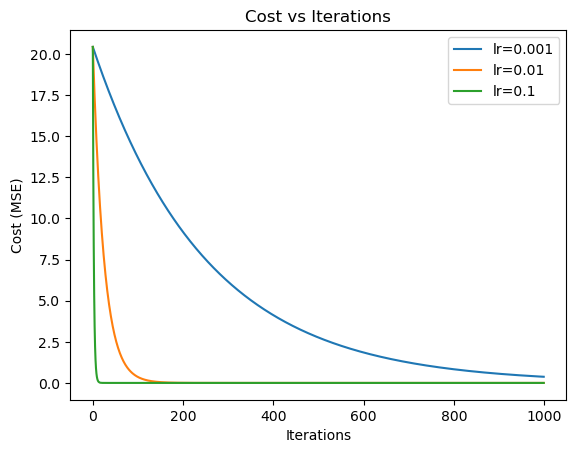

Iteration 0: m=0.0170, c=0.0887, Cost=20.4238
Iteration 100: m=0.7415, c=3.8608, Cost=0.3651
Iteration 200: m=0.8376, c=4.3610, Cost=0.0123
Iteration 300: m=0.8503, c=4.4274, Cost=0.0061
Iteration 400: m=0.8520, c=4.4362, Cost=0.0060
Iteration 500: m=0.8522, c=4.4373, Cost=0.0060
Iteration 600: m=0.8522, c=4.4375, Cost=0.0060
Iteration 700: m=0.8522, c=4.4375, Cost=0.0060
Iteration 800: m=0.8522, c=4.4375, Cost=0.0060
Iteration 900: m=0.8522, c=4.4375, Cost=0.0060


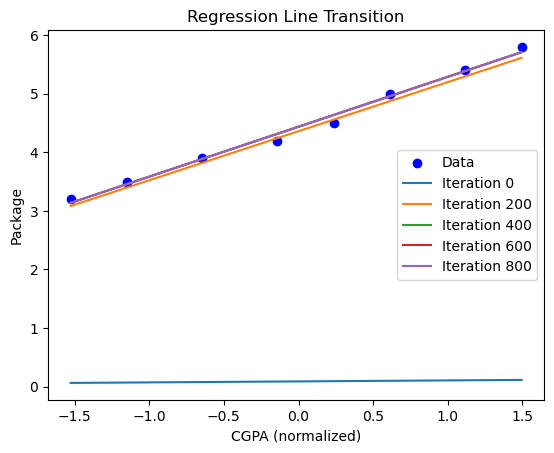


Final Evaluation:
m = 0.8522, c = 4.4375
MSE = 0.0060
RMSE = 0.0777


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "CGPA": [6.8, 7.1, 7.5, 7.9, 8.2, 8.5, 8.9, 9.2],
    "Package": [3.2, 3.5, 3.9, 4.2, 4.5, 5.0, 5.4, 5.8]
}
df = pd.DataFrame(data)

X = df["CGPA"].values
y = df["Package"].values

X = (X - X.mean()) / X.std()

def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

def gradient_descent(X, y, lr=0.01, iterations=1000):
    m, c = 0, 0
    n = len(y)
    cost_history = []
    params_history = []

    for i in range(iterations):
        y_pred = m * X + c
        error = y - y_pred

        dm = -(2/n) * np.dot(X, error)
        dc = -(2/n) * np.sum(error)

        m -= lr * dm
        c -= lr * dc

        cost = mse(y, y_pred)
        cost_history.append(cost)
        params_history.append((m, c))

        if i % 100 == 0:
            print(f"Iteration {i}: m={m:.4f}, c={c:.4f}, Cost={cost:.4f}")

    return m, c, cost_history, params_history

learning_rates = [0.001, 0.01, 0.1]

for lr in learning_rates:
    print(f"\n=== Learning Rate: {lr} ===")
    m, c, cost_history, params_history = gradient_descent(X, y, lr=lr, iterations=1000)

    plt.plot(range(len(cost_history)), cost_history, label=f"lr={lr}")

plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Cost vs Iterations")
plt.legend()
plt.show()

m, c, cost_history, params_history = gradient_descent(X, y, lr=0.01, iterations=1000)

plt.scatter(X, y, color="blue", label="Data")

for i in range(0, 1000, 200):
    m_i, c_i = params_history[i]
    plt.plot(X, m_i * X + c_i, label=f"Iteration {i}")

plt.xlabel("CGPA (normalized)")
plt.ylabel("Package")
plt.title("Regression Line Transition")
plt.legend()
plt.show()

y_pred_final = m * X + c
final_mse = mse(y, y_pred_final)
final_rmse = np.sqrt(final_mse)

print("\nFinal Evaluation:")
print(f"m = {m:.4f}, c = {c:.4f}")
print(f"MSE = {final_mse:.4f}")
print(f"RMSE = {final_rmse:.4f}")


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
data = {
    "CGPA": [6.8, 7.1, 7.5, 7.9, 8.2, 8.5, 8.9, 9.2],
    "Package": [3.2, 3.5, 3.9, 4.2, 4.5, 5.0, 5.4, 5.8]
}
df = pd.DataFrame(data)

X = df["CGPA"].values
y = df["Package"].values

X = (X - X.mean()) / X.std()

In [9]:
def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

def gradient_descent(X, y, lr=0.01, iterations=1000):
    m, c = 0, 0
    n = len(y)
    cost_history = []
    params_history = []

    for i in range(iterations):
        y_pred = m * X + c
        error = y - y_pred

        dm = -(2/n) * np.dot(X, error)
        dc = -(2/n) * np.sum(error)

        m -= lr * dm
        c -= lr * dc

        cost = mse(y, y_pred)
        cost_history.append(cost)
        params_history.append((m, c))

        if i % 100 == 0:
            print(f"Iteration {i}: m={m:.4f}, c={c:.4f}, Cost={cost:.4f}")

    return m, c, cost_history, params_history



=== Learning Rate: 0.001 ===
Iteration 0: m=0.0017, c=0.0089, Cost=20.4238
Iteration 100: m=0.1560, c=0.8124, Cost=13.6870
Iteration 200: m=0.2823, c=1.4701, Cost=9.1730
Iteration 300: m=0.3857, c=2.0085, Cost=6.1483
Iteration 400: m=0.4704, c=2.4492, Cost=4.1217
Iteration 500: m=0.5397, c=2.8099, Cost=2.7637
Iteration 600: m=0.5964, c=3.1052, Cost=1.8538
Iteration 700: m=0.6428, c=3.3469, Cost=1.2442
Iteration 800: m=0.6808, c=3.5448, Cost=0.8356
Iteration 900: m=0.7119, c=3.7068, Cost=0.5619

=== Learning Rate: 0.01 ===
Iteration 0: m=0.0170, c=0.0887, Cost=20.4238
Iteration 100: m=0.7415, c=3.8608, Cost=0.3651
Iteration 200: m=0.8376, c=4.3610, Cost=0.0123
Iteration 300: m=0.8503, c=4.4274, Cost=0.0061
Iteration 400: m=0.8520, c=4.4362, Cost=0.0060
Iteration 500: m=0.8522, c=4.4373, Cost=0.0060
Iteration 600: m=0.8522, c=4.4375, Cost=0.0060
Iteration 700: m=0.8522, c=4.4375, Cost=0.0060
Iteration 800: m=0.8522, c=4.4375, Cost=0.0060
Iteration 900: m=0.8522, c=4.4375, Cost=0.0060

=

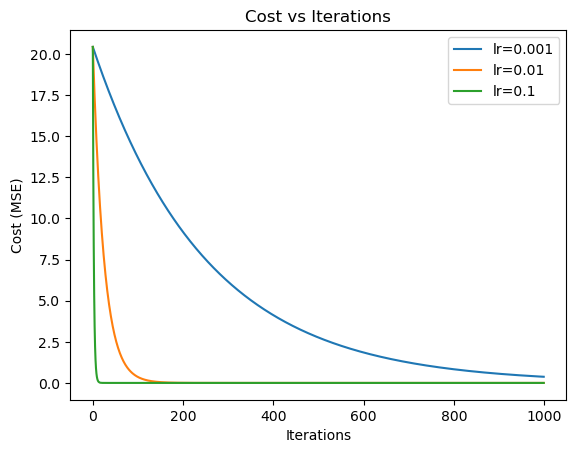

Iteration 0: m=0.0170, c=0.0887, Cost=20.4238
Iteration 100: m=0.7415, c=3.8608, Cost=0.3651
Iteration 200: m=0.8376, c=4.3610, Cost=0.0123
Iteration 300: m=0.8503, c=4.4274, Cost=0.0061
Iteration 400: m=0.8520, c=4.4362, Cost=0.0060
Iteration 500: m=0.8522, c=4.4373, Cost=0.0060
Iteration 600: m=0.8522, c=4.4375, Cost=0.0060
Iteration 700: m=0.8522, c=4.4375, Cost=0.0060
Iteration 800: m=0.8522, c=4.4375, Cost=0.0060
Iteration 900: m=0.8522, c=4.4375, Cost=0.0060


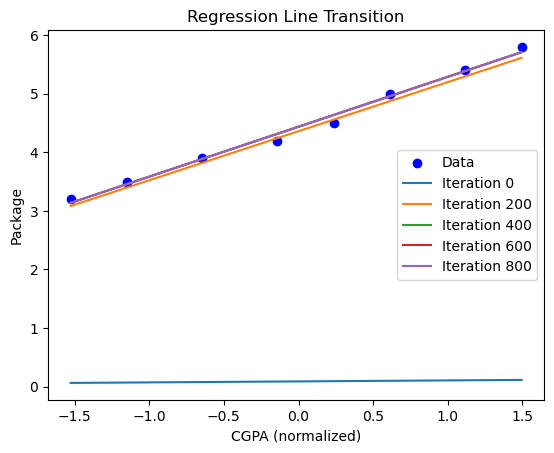


Final Evaluation:
m = 0.8522, c = 4.4375
MSE = 0.0060
RMSE = 0.0777


In [10]:
learning_rates = [0.001, 0.01, 0.1]

for lr in learning_rates:
    print(f"\n=== Learning Rate: {lr} ===")
    m, c, cost_history, params_history = gradient_descent(X, y, lr=lr, iterations=1000)

    plt.plot(range(len(cost_history)), cost_history, label=f"lr={lr}")

plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Cost vs Iterations")
plt.legend()
plt.show()

m, c, cost_history, params_history = gradient_descent(X, y, lr=0.01, iterations=1000)

plt.scatter(X, y, color="blue", label="Data")

for i in range(0, 1000, 200):
    m_i, c_i = params_history[i]
    plt.plot(X, m_i * X + c_i, label=f"Iteration {i}")

plt.xlabel("CGPA (normalized)")
plt.ylabel("Package")
plt.title("Regression Line Transition")
plt.legend()
plt.show()

y_pred_final = m * X + c
final_mse = mse(y, y_pred_final)
final_rmse = np.sqrt(final_mse)

print("\nFinal Evaluation:")
print(f"m = {m:.4f}, c = {c:.4f}")
print(f"MSE = {final_mse:.4f}")
print(f"RMSE = {final_rmse:.4f}")


In [11]:
x = abs(-4)

In [12]:
print(x)

4
